
# SDXL LoRA Fine-Tuning (Local Parquet) — Robust Decoder + Proper HF Image Feature

This notebook fine-tunes **Stable Diffusion XL** with **LoRA** using your **local AdImageNet Parquet shards**.
It fixes the previous `ArrowInvalid` by constructing the Hugging Face dataset with explicit `Features` and the `Image()` feature (so PIL images are accepted).

**Sections**
1) Install (if needed)  
2) Config — local parquet paths  
3) Load & merge parquet  
4) Inspect image field & select column  
5) Build size-aware prompts  
6) Robust image decoder (bytes/base64/Arrow/URL/path/dict/numpy)  
7) Build HF `Dataset` using `Features({'image': Image(), 'prompt': Value('string')})` ✅  
8) (Optional) Export snapshot for `--train_data_dir`  
9) Train LoRA (command printed)  
10) Inference


## 0) Install (if needed)

In [1]:

# !pip install -U "diffusers[torch]" transformers accelerate datasets safetensors torchvision pillow pyarrow pandas numpy requests
# !pip install -U git+https://github.com/huggingface/diffusers


## 1) Config — set your local Parquet paths

In [2]:

PARQUET_FILES = [
    "/Users/jjburrell/Downloads/train-00000-of-00002-6e587552aa3c8ac8.parquet",
    "/Users/jjburrell/Downloads/train-00001-of-00002-823ac5dae71e0e87.parquet",
]

MODEL_NAME = "stabilityai/stable-diffusion-xl-base-1.0"
OUTPUT_DIR = "lora_adimage_sdxl"
PROMPT_STYLE = "clean promotional layout, sharp text, high contrast."

RESOLUTION = 1024
TRAIN_BATCH_SIZE = 2
GRAD_ACCUM = 4
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
LR_WARMUP = 500
RANK = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
MIXED_PRECISION = "fp16"
TRAIN_TEXT_ENCODER = True

SNAPSHOT_DIR = "adimagenet_snapshot_local"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output dir:", OUTPUT_DIR)


Output dir: lora_adimage_sdxl


## 2) Load & merge Parquet

In [3]:

import pandas as pd, os
assert all(os.path.exists(p) for p in PARQUET_FILES), "One or more Parquet paths do not exist."
dfs = [pd.read_parquet(p) for p in PARQUET_FILES]
df = pd.concat(dfs, ignore_index=True)
print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head(2)


Rows: 9003
Columns: ['image', 'text', 'dimensions']


,image,text,dimensions
0,{'bytes': b'\xff\xd8\xff\xe1\x00\x18Exif\x00\x...,Supplements You Trust\nOrganix\nResults You Lo...,"(160, 600)"
1,{'bytes': b'\xff\xd8\xff\xe1\x00HExif\x00\x00I...,$3\nSTULZ\nDifferential for 2nd Shift\nManufac...,"(300, 250)"


## 3) Inspect the image field & choose the column

In [4]:

row0 = df.iloc[0].to_dict()
print("=== Sample types from first row ===")
for k, v in row0.items():
    t = type(v).__name__
    extra = ""
    if isinstance(v, dict):
        extra = f" keys={list(v.keys())[:10]}"
    print(f"{k:20s} -> {t}{extra}")

# Auto-pick the image column (looks for dict with 'bytes' or 'path', or bytes-like column)
CANDIDATES = ["image","image_bytes","img","content","data","image_data","bytes","blob","jpg","png","image_b64","b64","image_url","url","path","filepath","image_path"]
IMAGE_COL = None
for c in CANDIDATES:
    if c in df.columns:
        IMAGE_COL = c; break
if IMAGE_COL is None:
    for c in df.columns:
        v = df.iloc[0][c]
        if isinstance(v, (bytes, bytearray)) or hasattr(v, "as_py"):
            IMAGE_COL = c; break
        if isinstance(v, dict) and any(k in v for k in ("bytes","data","b64","base64","url","path","filepath","image")):
            IMAGE_COL = c; break
print("\nChosen IMAGE_COL:", IMAGE_COL)
if IMAGE_COL is None:
    raise RuntimeError("Could not detect an image-like column. Set IMAGE_COL manually.")


=== Sample types from first row ===
image                -> dict keys=['bytes', 'path']
text                 -> str
dimensions           -> str

Chosen IMAGE_COL: image


## 4) Build size-aware prompts

In [5]:

def build_prompt(row):
    wh = row.get("ad_size") or row.get("dimensions") or [300, 250]
    # dimensions might be a string like "300x250" — parse
    if isinstance(wh, str) and "x" in wh:
        try:
            w, h = [int(x) for x in wh.lower().split("x")[:2]]
        except Exception:
            w, h = 300, 250
    else:
        try:
            w, h = int(wh[0]), int(wh[1])
        except Exception:
            w, h = 300, 250
    size_txt = f"banner {w}x{h}"
    txt = (row.get("creative_text") or row.get("text") or "").strip()
    txt = " ".join(txt.split())
    return f"{size_txt}. {PROMPT_STYLE} {txt}"[:256]

df["prompt"] = df.apply(build_prompt, axis=1)
print("Prompt example:", df.iloc[0]["prompt"][:200])


Prompt example: banner 300x250. clean promotional layout, sharp text, high contrast. Supplements You Trust Organix Results You Love Organi MAGNESIUM Iak Dietary Supplement 001 14,000+ 5 STAR REVIEWS Organixor Magnesi


## 5) Robust image decoder (bytes/base64/Arrow/URL/path/dict/numpy)

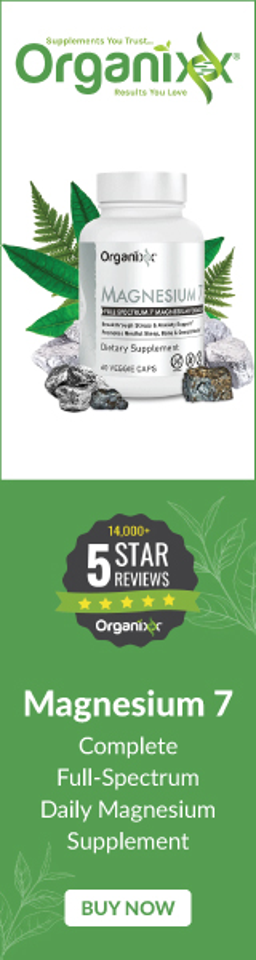

In [6]:

from PIL import Image
import os, io, base64, requests, numpy as np

def _open_from_bytes(buf: bytes) -> Image.Image:
    return Image.open(io.BytesIO(buf)).convert("RGB")

def _maybe_arrow_as_py(x):
    return x.as_py() if hasattr(x, "as_py") else x

def decode_image_any(x):
    x = _maybe_arrow_as_py(x)

    # PIL already
    if isinstance(x, Image.Image):
        return x.convert("RGB")

    # bytes-like
    if isinstance(x, (bytes, bytearray, memoryview)):
        return _open_from_bytes(bytes(x))

    # numpy arrays
    if isinstance(x, np.ndarray):
        if x.dtype == np.uint8:
            if x.ndim == 3:  # HWC
                return Image.fromarray(x, "RGB") if x.shape[2] >= 3 else Image.fromarray(x.squeeze(-1), "L").convert("RGB")
            if x.ndim == 2:  # HW
                return Image.fromarray(x, "L").convert("RGB")
            if x.ndim == 1:  # maybe encoded stream
                try:
                    return _open_from_bytes(x.tobytes())
                except Exception:
                    pass
        # try as encoded
        try:
            return _open_from_bytes(x.tobytes())
        except Exception:
            pass

    # list/tuple -> try numpy
    if isinstance(x, (list, tuple)):
        try:
            arr = np.array(x)
            return decode_image_any(arr)
        except Exception:
            pass

    # string: path / url / base64
    if isinstance(x, str):
        s = x.strip()
        if os.path.exists(s):
            return Image.open(s).convert("RGB")
        if s.startswith("http://") or s.startswith("https://"):
            r = requests.get(s, timeout=10)
            r.raise_for_status()
            return _open_from_bytes(r.content)
        try:
            return _open_from_bytes(base64.b64decode(s))
        except Exception:
            pass

    # dict container: handle keys from your sample ['bytes','path']
    if isinstance(x, dict):
        x = {k: _maybe_arrow_as_py(v) for k, v in x.items()}
        if "bytes" in x and isinstance(x["bytes"], (bytes, bytearray, memoryview)):
            return _open_from_bytes(bytes(x["bytes"]))
        if "path" in x and isinstance(x["path"], str) and os.path.exists(x["path"]):
            return Image.open(x["path"]).convert("RGB")
        # generic fallbacks
        for key in ("image","data","buffer"):
            if key in x and isinstance(x[key], (bytes, bytearray, memoryview)):
                return _open_from_bytes(bytes(x[key]))
        for key in ("b64","base64"):
            if key in x and isinstance(x[key], str):
                return _open_from_bytes(base64.b64decode(x[key]))
        for key in ("url","image_url"):
            if key in x and isinstance(x[key], str) and (x[key].startswith("http://") or x[key].startswith("https://")):
                r = requests.get(x[key], timeout=10)
                r.raise_for_status()
                return _open_from_bytes(r.content)
        for key in ("path","filepath","image_path","file"):
            if key in x and isinstance(x[key], str) and os.path.exists(x[key]):
                return Image.open(x[key]).convert("RGB")

    raise ValueError("Unsupported image format/encoding")

# Preview
raw0 = df.iloc[0][IMAGE_COL]
img0 = decode_image_any(raw0)
display(img0.resize((256, int(256*img0.height/img0.width))))


## 6) Build Hugging Face `Dataset` with explicit Features (fixes ArrowInvalid)

/Users/jjburrell/Econometrics/Econometrics/.venv/lib/python3.13/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Dataset({
    features: ['image', 'prompt'],
    num_rows: 9003
})


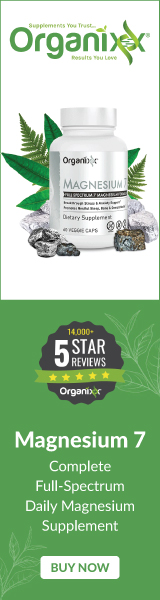

banner 300x250. clean promotional layout, sharp text, high contrast. Supplements You Trust Organix Results You Love Organi MAGNESIUM Iak Dietary Supplement 001 14,000+ 5 STAR REVIEWS Organixor Magnesi


In [7]:

from datasets import Dataset, Features, Value
from datasets import Image as HFImage

# Decode all images to PIL and build the dataset from dict
images = []
prompts = []
for i, row in df.iterrows():
    try:
        images.append(decode_image_any(row[IMAGE_COL]))
    except Exception:
        images.append(Image.new("RGB", (512,512), (255,255,255)))
    prompts.append(row["prompt"])

features = Features({
    "image": HFImage(),             # this is the key: tells HF to accept PIL images
    "prompt": Value("string")
})

ds = Dataset.from_dict({"image": images, "prompt": prompts}, features=features)
print(ds)
display(ds[0]["image"]); print(ds[0]["prompt"][:200])


## 7) (Optional) Export snapshot for `--train_data_dir`

In [8]:

import csv, pathlib, os
IMG_DIR = os.path.join(SNAPSHOT_DIR, "images")
pathlib.Path(IMG_DIR).mkdir(parents=True, exist_ok=True)

rows = []
for i, ex in enumerate(ds):
    p = os.path.join(IMG_DIR, f"{i:06d}.png")
    ex["image"].save(p, "PNG")
    rows.append({"file": p, "text": ex["prompt"]})

with open(os.path.join(SNAPSHOT_DIR, "captions.csv"), "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file","text"])
    writer.writeheader()
    writer.writerows(rows)

print("Saved", len(rows), "examples to", SNAPSHOT_DIR)


Saved 9003 examples to adimagenet_snapshot_local


## 8) Train LoRA (Diffusers official script)

In [9]:

cmd = f'''
accelerate launch -m diffusers.examples.text_to_image.train_text_to_image_lora \
  --pretrained_model_name_or_path "{MODEL_NAME}" \
  --train_data_dir "{SNAPSHOT_DIR}" \
  --caption_column "text" \
  --resolution {RESOLUTION} --center_crop --random_flip \
  --train_text_encoder \
  --rank {RANK} --lora_alpha {LORA_ALPHA} --lora_dropout {LORA_DROPOUT} \
  --mixed_precision {MIXED_PRECISION} --gradient_checkpointing \
  --learning_rate {LEARNING_RATE} --lr_scheduler cosine --lr_warmup_steps {LR_WARMUP} \
  --train_batch_size {TRAIN_BATCH_SIZE} --gradient_accumulation_steps {GRAD_ACCUM} \
  --num_train_epochs {NUM_EPOCHS} --checkpointing_steps 1000 \
  --output_dir "{OUTPUT_DIR}"
'''.strip()
print(cmd)


accelerate launch -m diffusers.examples.text_to_image.train_text_to_image_lora   --pretrained_model_name_or_path "stabilityai/stable-diffusion-xl-base-1.0"   --train_data_dir "adimagenet_snapshot_local"   --caption_column "text"   --resolution 1024 --center_crop --random_flip   --train_text_encoder   --rank 8 --lora_alpha 16 --lora_dropout 0.05   --mixed_precision fp16 --gradient_checkpointing   --learning_rate 0.0001 --lr_scheduler cosine --lr_warmup_steps 500   --train_batch_size 2 --gradient_accumulation_steps 4   --num_train_epochs 5 --checkpointing_steps 1000   --output_dir "lora_adimage_sdxl"


## 9) Inference

In [11]:
import os
import torch
from glob import glob
from typing import Optional, Tuple
from diffusers import AutoPipelineForText2Image
from PIL import Image

def get_device_and_dtype() -> Tuple[str, torch.dtype]:
    if torch.cuda.is_available():
        return "cuda", torch.float16
    if torch.backends.mps.is_available():
        return "mps", torch.float16
    return "cpu", torch.float32

def safe_cast_modules(pipe, dtype: torch.dtype) -> None:
    try:
        pipe.unet.to(dtype=dtype)
        pipe.vae.to(dtype=dtype)
        if hasattr(pipe, "text_encoder"):
            pipe.text_encoder.to(dtype=dtype)
        if hasattr(pipe, "text_encoder_2"):
            pipe.text_encoder_2.to(dtype=dtype)
    except Exception as err:
        print("Module cast warning:", err)

def init_pipeline(model_name: str):
    device, dtype = get_device_and_dtype()
    pipe = AutoPipelineForText2Image.from_pretrained(model_name).to(device)
    safe_cast_modules(pipe, dtype)
    print(f"Using device={device}, dtype={dtype}")
    return pipe, device, dtype

def find_latest_lora(output_dir: str) -> Optional[str]:
    if not os.path.isdir(output_dir):
        return None
    patterns = ("*.safetensors", "*.bin", "*.pt")
    candidates = []
    for pattern in patterns:
        candidates.extend(glob(os.path.join(output_dir, "**", pattern), recursive=True))
    if not candidates:
        return None
    candidates.sort(key=os.path.getmtime)
    return candidates[-1]

def load_local_lora(pipe, output_dir: str) -> bool:
    lora_path = find_latest_lora(output_dir)
    if not lora_path:
        print(f"No LoRA weights found inside {output_dir}. Run training or set OUTPUT_DIR to your checkpoint.")
        return False
    weight_dir = os.path.dirname(lora_path)
    weight_name = os.path.basename(lora_path)
    try:
        pipe.load_lora_weights(weight_dir, weight_name=weight_name)
        print("Loaded LoRA:", lora_path)
        return True
    except Exception as err:
        print(f"Failed to load LoRA at {lora_path}: {err}")
        return False

pipe, device, dtype = init_pipeline(MODEL_NAME)

if not load_local_lora(pipe, OUTPUT_DIR):
    print("Continuing without LoRA adapter.")

prompt = "banner 300x250. clean promotional layout, bold headline, CTA button bottom-right, high contrast. summer shoe sale 20% off, free shipping."
hi = RESOLUTION
img = pipe(prompt, num_inference_steps=28, guidance_scale=5.0, height=hi, width=hi).images[0]

target_w, target_h = 300, 250
img_small = img.resize((target_w, target_h), Image.LANCZOS)
os.makedirs("samples", exist_ok=True)
out_path = f"samples/ad_{target_w}x{target_h}.png"
img_small.save(out_path)
out_path, img_small



model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


LoRA not found yet. Train first or set OUTPUT_DIR to your checkpoint. Error: PEFT backend is required for this method.


  0%|          | 0/28 [00:00<?, ?it/s]

('samples/ad_300x250.png', <PIL.Image.Image image mode=RGB size=300x250>)